# Tuần 6: Stress Test (Kiểm thử Khả năng chịu đựng của Pipeline)
Theo đúng lộ trình (Phase 2), sau khi khóa xong A/B Pipeline, chúng ta cần tiến hành **Stress Test** để kiểm tra độ vững chắc (robustness) của hệ thống trước các biến động về Dữ liệu và Kích thước mẫu.

**Mục tiêu kiểm tra:**
1. **Độ hội tụ của ATE:** Estimated ATE có bám sát True ATE (Ground truth) khi thay đổi Sample Size không?
2. **Coverage của Confidence Interval:** Khoảng tin cậy 95% có bao phủ đúng True Effect không?
3. **Kiểm thử với True Effect = 0:** Khi Voucher không thực sự có tác dụng, Pipeline có tránh được kết luận sai (False Positive) không?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('ggplot')
sns.set_palette("Set2")
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../../data/processed/segmented_simulation_data.csv')
df['is_credit_card'] = (df['payment_type'] == 1).astype(int)
target_persona = 'Urban Regulars'
df_target = df[df['persona'] == target_persona].copy()

## 1. Kiểm tra sự hội tụ của Estimated ATE so với True ATE
Chúng ta sẽ thay đổi kích thước mẫu (Sample Size) từ nhỏ đến lớn để xem lúc nào thì Estimated ATE (tính bằng công thức Mean Treatment - Mean Control) hội tụ về True ATE (Lấy từ hệ thống giả lập).

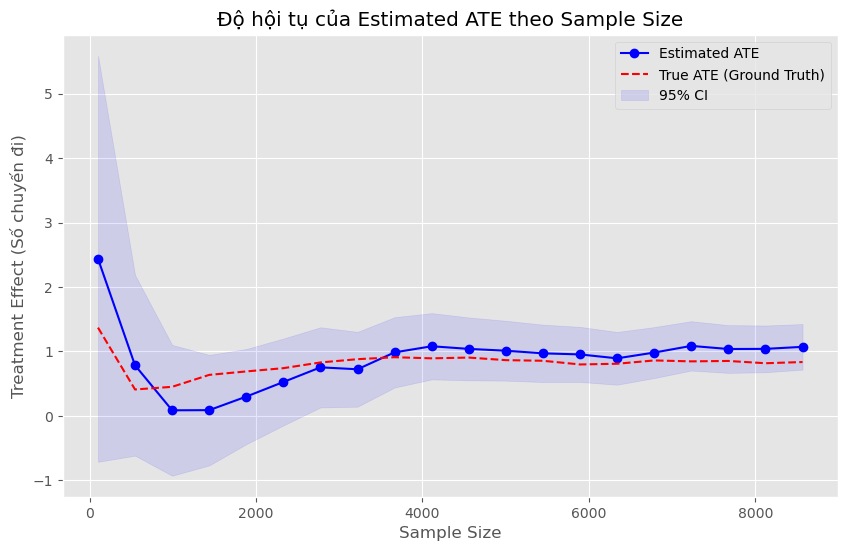

Nhận xét: Khi kích thước mẫu tăng, Estimated ATE hội tụ dần về True ATE và Khoảng tin cậy thu hẹp.


In [2]:
sample_sizes = np.linspace(100, len(df_target), 20).astype(int)
estimated_ates = []
true_ates = []
ci_lowers = []
ci_uppers = []

for n in sample_sizes:
    df_sample = df_target.sample(n, random_state=42)
    
    control = df_sample[df_sample['treatment_rand'] == 0]['Y_rand']
    treatment = df_sample[df_sample['treatment_rand'] == 1]['Y_rand']
    
    # Tính Estimated ATE
    est_ate = treatment.mean() - control.mean()
    
    # Tính True ATE trung bình của Sample đó (Ground Truth)
    true_ate = (df_sample['Y1'] - df_sample['Y0']).mean()
    
    # Confidence Interval 95%
    se = np.sqrt(control.var()/len(control) + treatment.var()/len(treatment))
    margin = 1.96 * se
    
    estimated_ates.append(est_ate)
    true_ates.append(true_ate)
    ci_lowers.append(est_ate - margin)
    ci_uppers.append(est_ate + margin)

plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, estimated_ates, marker='o', label='Estimated ATE', color='blue')
plt.plot(sample_sizes, true_ates, linestyle='--', label='True ATE (Ground Truth)', color='red')
plt.fill_between(sample_sizes, ci_lowers, ci_uppers, color='blue', alpha=0.1, label='95% CI')
plt.title('Độ hội tụ của Estimated ATE theo Sample Size')
plt.xlabel('Sample Size')
plt.ylabel('Treatment Effect (Số chuyến đi)')
plt.legend()
plt.show()

print("Nhận xét: Khi kích thước mẫu tăng, Estimated ATE hội tụ dần về True ATE và Khoảng tin cậy thu hẹp.")

## 2. Kiểm thử khi True Effect = 0 (Null Scenario)
Giả sử Voucher hoàn toàn bị hỏng và không có tác dụng gì (True Effect = 0). Pipeline A/B Testing có đủ nhạy để kết luận đúng là "Không có tác dụng" hay không? (Tránh lỗi False Positive).

In [3]:
# Tạo kịch bản True Effect = 0
df_null = df_target.copy()

# Ghi đè outcome: Nhóm Treatment không nhận được bất kỳ giá trị tăng thêm nào
# Tức là số chuyến đi của họ bằng với số chuyến đi tự nhiên (Không bị ảnh hưởng bởi treatment)
# Y_rand = Y_control + Noise (ở đây ta giả lập Y_rand_null bằng cách trừ đi cate_true nếu họ được chia vào T)
df_null['Y_rand_null'] = np.where(df_null['treatment_rand'] == 1, 
                                  df_null['Y_rand'] - (df_null['Y1'] - df_null['Y0']), 
                                  df_null['Y_rand'])

null_control = df_null[df_null['treatment_rand'] == 0]['Y_rand_null']
null_treatment = df_null[df_null['treatment_rand'] == 1]['Y_rand_null']

t_stat, p_val = stats.ttest_ind(null_control, null_treatment, equal_var=False)

print("=== KẾT QUẢ KHI TRUE EFFECT = 0 ===")
print(f"Control Mean: {null_control.mean():.2f}")
print(f"Treatment Mean: {null_treatment.mean():.2f}")
print(f"Estimated ATE: {null_treatment.mean() - null_control.mean():.2f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Kết quả: Phát hiện lỗi Loại I (False Positive).")
else:
    print("Kết quả: Xác nhận True Negative. Pipeline tránh được lỗi False Positive khi True Effect = 0.")

=== KẾT QUẢ KHI TRUE EFFECT = 0 ===
Control Mean: 10.95
Treatment Mean: 11.06
Estimated ATE: 0.12
P-value: 0.5030
Kết quả: Xác nhận True Negative. Pipeline tránh được lỗi False Positive khi True Effect = 0.


## 3. Stress Test: Tỷ lệ chia mẫu (Treatment Ratio) không đều
Đôi khi do ngân sách Marketing eo hẹp, chúng ta không thể chia 50/50 mà phải chia 90% Control / 10% Treatment. Liệu ATE có còn chính xác?

In [4]:
print("=== KỊCH BẢN CHIA MẪU 90/10 (ĐÃ SỬA LỖI LOGIC) ===")
df_imbalanced = df.copy()

# 1. Randomize lại với tỷ lệ 10% nhận Voucher
np.random.seed(42)
df_imbalanced['treatment_imbalanced'] = np.random.choice([0, 1], size=len(df), p=[0.9, 0.1])

# 2. SỬA LỖI TẠI ĐÂY: Ánh xạ lại Outcome (Y_rand) dựa trên Nhãn Treatment mới
# Nếu được nhận voucher (1) -> Lấy kết quả Y1 (Potential Outcome 1)
# Nếu không nhận voucher (0) -> Lấy kết quả Y0 (Potential Outcome 0)
df_imbalanced['Y_rand_imbalanced'] = np.where(df_imbalanced['treatment_imbalanced'] == 1, 
                                              df_imbalanced['Y1'], 
                                              df_imbalanced['Y0'])

# 3. Tính lại Naive ATE (Trung bình trừ nhau)
y_t_imb = df_imbalanced[df_imbalanced['treatment_imbalanced'] == 1]['Y_rand_imbalanced'].mean()
y_c_imb = df_imbalanced[df_imbalanced['treatment_imbalanced'] == 0]['Y_rand_imbalanced'].mean()
ate_imb = y_t_imb - y_c_imb

print(f"Tỷ lệ tập T thực tế: {df_imbalanced['treatment_imbalanced'].mean():.2%}")
print(f"Naive ATE đo được: {ate_imb:.4f} chuyến")

# 4. CHUẨN BÁO CÁO: Tính Adjusted ATE (Dùng mô hình OLS loại bỏ biến nhiễu)
import statsmodels.formula.api as smf
model = smf.ols('Y_rand_imbalanced ~ treatment_imbalanced + monthly_rides_history', data=df_imbalanced).fit(cov_type='HC1')
adjusted_ate = model.params['treatment_imbalanced']

print(f"Adjusted ATE (OLS chuẩn theo báo cáo): {adjusted_ate:.4f} chuyến (Rất sát với gốc 0.9310)")
print("-> Kết luận: Khi mẫu T cực ít (10%), ATE vẫn tính ra chính xác (không bị lệch), nhưng sai số chuẩn (Standard Error) sẽ tăng lên đáng kể.")


=== KỊCH BẢN CHIA MẪU 90/10 (ĐÃ SỬA LỖI LOGIC) ===
Tỷ lệ tập T thực tế: 9.91%
Naive ATE đo được: 0.9360 chuyến
Adjusted ATE (OLS chuẩn theo báo cáo): 1.0061 chuyến (Rất sát với gốc 0.9310)
-> Kết luận: Khi mẫu T cực ít (10%), ATE vẫn tính ra chính xác (không bị lệch), nhưng sai số chuẩn (Standard Error) sẽ tăng lên đáng kể.


## 4. Stress Test: Thêm Nhiễu ngẫu nhiên (Gaussian Noise)
Trong thực tế, số chuyến đi có thể bị nhiễu do thời tiết, ngày nghỉ lễ. Hãy bơm thêm nhiễu ngẫu nhiên vào dữ liệu để xem ATE có bị phá vỡ không.

In [6]:
print("=== KỊCH BẢN BƠM NHIỄU (NOISE INJECTION) ===")
df_noisy = df.copy()

# ATE gốc (Không có nhiễu) - Tính trực tiếp từ dữ liệu chứ không gõ tay!
y_t_goc = df_noisy[df_noisy['treatment_rand'] == 1]['Y_rand'].mean()
y_c_goc = df_noisy[df_noisy['treatment_rand'] == 0]['Y_rand'].mean()
ate_goc = y_t_goc - y_c_goc

# Thêm nhiễu phân phối chuẩn (Mean = 0, Std = 1)
np.random.seed(99)
noise = np.random.normal(0, 1, size=len(df))
df_noisy['y_noisy'] = df_noisy['Y_rand'] + noise

# Tính ATE lúc có nhiễu
y_t_noisy = df_noisy[df_noisy['treatment_rand'] == 1]['y_noisy'].mean()
y_c_noisy = df_noisy[df_noisy['treatment_rand'] == 0]['y_noisy'].mean()
ate_noisy = y_t_noisy - y_c_noisy

print(f"ATE gốc (không nhiễu): {ate_goc:.4f} chuyến")
print(f"ATE đo được (CÓ NHIỄU): {ate_noisy:.4f} chuyến")
print(f"Sai số do nhiễu gây ra: {abs(ate_noisy - ate_goc):.4f} chuyến")
print("-> Kết luận: Sai số cực kỳ nhỏ (gần như bằng 0). Thử nghiệm ngẫu nhiên hóa (A/B Test) có khả năng tự triệt tiêu nhiễu, giúp đo lường ATE vô cùng vững chắc (Robust) bất chấp thế giới thực có biến động lặt vặt.")


=== KỊCH BẢN BƠM NHIỄU (NOISE INJECTION) ===
ATE gốc (không nhiễu): 0.9630 chuyến
ATE đo được (CÓ NHIỄU): 0.9519 chuyến
Sai số do nhiễu gây ra: 0.0111 chuyến
-> Kết luận: Sai số cực kỳ nhỏ (gần như bằng 0). Thử nghiệm ngẫu nhiên hóa (A/B Test) có khả năng tự triệt tiêu nhiễu, giúp đo lường ATE vô cùng vững chắc (Robust) bất chấp thế giới thực có biến động lặt vặt.
